In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm.auto import tqdm

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

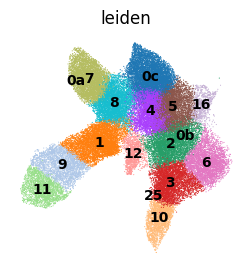

In [2]:
# load the truncated atlas : shape 49390, 4814
adata = sc.read_h5ad("data/tom_pos_updated.h5ad")
raw_ad = adata.raw.to_adata()

# load PINN inferred params
# g: (9, 49390) , v: (9, 49390, 10)
# g = np.load("results/tom_pos-DM_scaled_n9/pde_params_tsense_Dec04_onbase/version_0_g.npy")
# v = np.load("results/tom_pos-DM_scaled_n9/pde_params_tsense_Dec04_onbase/version_0_v.npy")
g = np.load("results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense_Dec06_onbase/version_4_g.npy")/15
v = np.load("results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense_Dec06_onbase/version_4_v.npy")/15



fig=plt.figure(figsize=(3,3), dpi=100)
sc.pl.umap(adata, color='leiden', legend_loc='on data', frameon=False, ax=fig.gca())

In [125]:
celltype_pallete = {"HSC":"#E278C6","Meg":"#AFC7E5","Mono/DC prog":"#FFC58B",
 "Int prog":"#C8C8C8","Ery":"#8C554A","Eos":"#AD40FC",
 "Neu":"#9BDD91","Bas/MC prog":"#279F6A","Ly":"#31C6D3"}

# ery marker

In [5]:
erythrocyte_markers = {
    "early_progenitors": [
        "Gata1",    # Master erythroid transcription factor
        "Klf1",      # Erythroid Krüppel-like factor (EKLF)
        "Tal1",      # T-cell acute lymphocytic leukemia protein 1 (SCL)
        "Epb4.2"     # Erythrocyte membrane protein band 4.2
    ],
    "intermediate_stages": [
        "Epor",      # Erythropoietin receptor
        "Hbb-b1",    # Hemoglobin subunit beta-1 (adult beta-globin)
        "Hba-a1",    # Hemoglobin subunit alpha-1 (adult alpha-globin)
        "Slc4a1",    # Band 3 (anion exchanger, erythrocyte membrane protein)
        "Gypa",      # Glycophorin A (erythrocyte membrane protein)
        "Ahsp",      # Alpha-hemoglobin stabilizing protein
        "Tfrc"       # Transferrin receptor (iron uptake)
    ],
    "mature_erythrocytes": [
        "Hbb-b1",    # Dominant beta-globin in mature RBCs
        "Hba-a1",    # Dominant alpha-globin in mature RBCs
        "Spna1",     # Alpha-spectrin (cytoskeletal protein)
        "Spnb1",     # Beta-spectrin (cytoskeletal protein)
        "Ank1",      # Ankyrin-1 (links membrane to cytoskeleton)
        "Epb4.2",    # Stabilizes membrane structure
        "Cd47",      # "Don’t eat me" signal to macrophages
        "Ly76"       # TER-119 antigen (cell surface marker)
    ]
}

<Figure size 300x300 with 0 Axes>

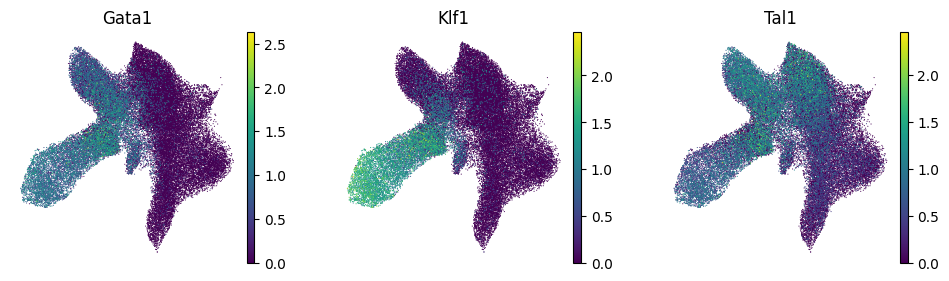

<Figure size 300x300 with 0 Axes>

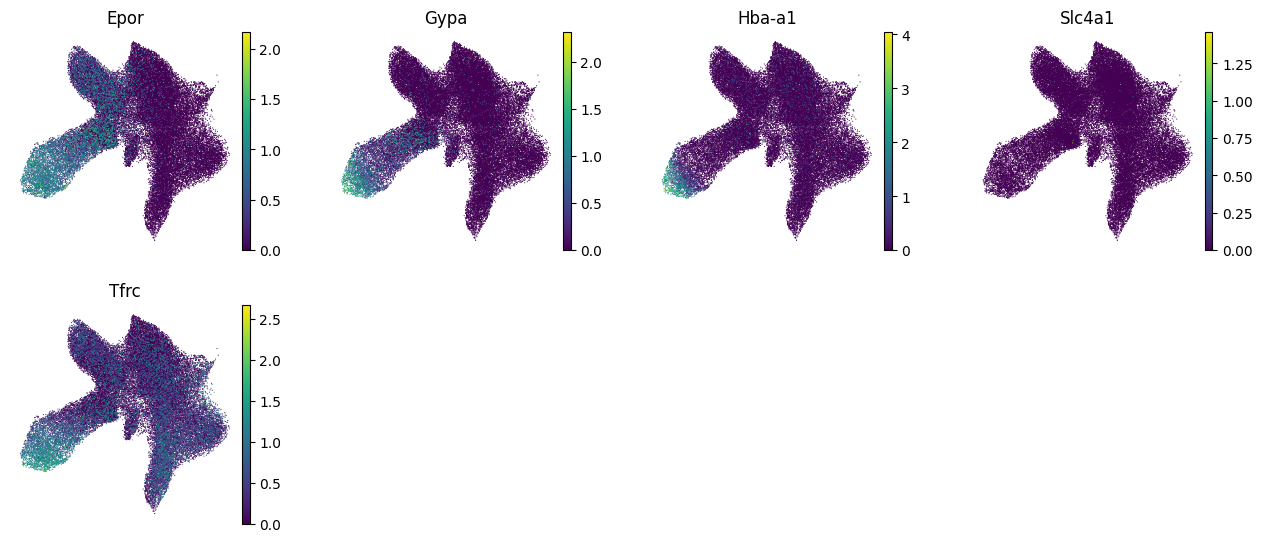

<Figure size 300x300 with 0 Axes>

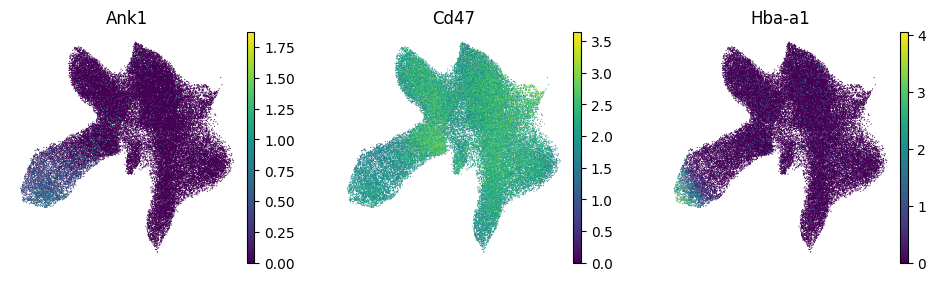

In [13]:
with plt.rc_context({"figure.figsize":(3,3), "figure.dpi":100}):
    for k,v in erythrocyte_markers.items():
        plt.suptitle(k)
        genes = np.intersect1d(v, raw_ad.var_names)
        sc.pl.umap(raw_ad, color=genes, legend_loc='on data', frameon=False)

# inspect params

In [12]:
for i,t in enumerate(adata.uns['pop']['t']):
    adata.obs[f'Day{t} g'] = g[i]

    v_std = v[i].std(axis=0,keepdims=True)
    v_scaled_norm = np.sqrt(np.sum((v[i]/v_std)**2, axis=1)) 
    adata.obs[f'Day{t} v norm'] = v_scaled_norm

In [13]:
# psdyn inferred params
cb_of_cluster = {}
param_df = []
for clu in [7,10,11]:
    param = pd.read_csv(f"data/HSCP_PD_params/clu{clu}/table_all_parameters_clu_{clu}.csv", index_col=0)
    param['leiden'] = str(clu)
    param_df.append(param)

    print(clu, param.shape)
    print(clu, np.intersect1d(adata.obs_names, param.index).shape)

    cb_of_cluster[str(clu)] = np.intersect1d(adata.obs_names, param.index)

param_df =  pd.concat(param_df)
param_df.head(3)

7 (8704, 7)
7 (8681,)
10 (19227, 7)
10 (19049,)
11 (16532, 7)
11 (16427,)


,dpt_pseudotime,dpt_pseudotime_scaled,diffusion,drift,dpt_pseudotime_scaled2,growth,leiden
9mo_SIGAE3_AAACCCAAGACCTCAT-1-10x,0.059012,0.578092,0.000114,0.097776,0.578354,-0.29758,7
9mo_SIGAE3_AAACGAATCTACGGTA-1-10x,0.057721,0.565515,0.000112,0.096416,0.565734,-0.25188,7
9mo_SIGAE3_AAACGCTTCCGTGCGA-1-10x,0.011457,0.114933,0.000061,0.016373,0.113636,0.11150,7


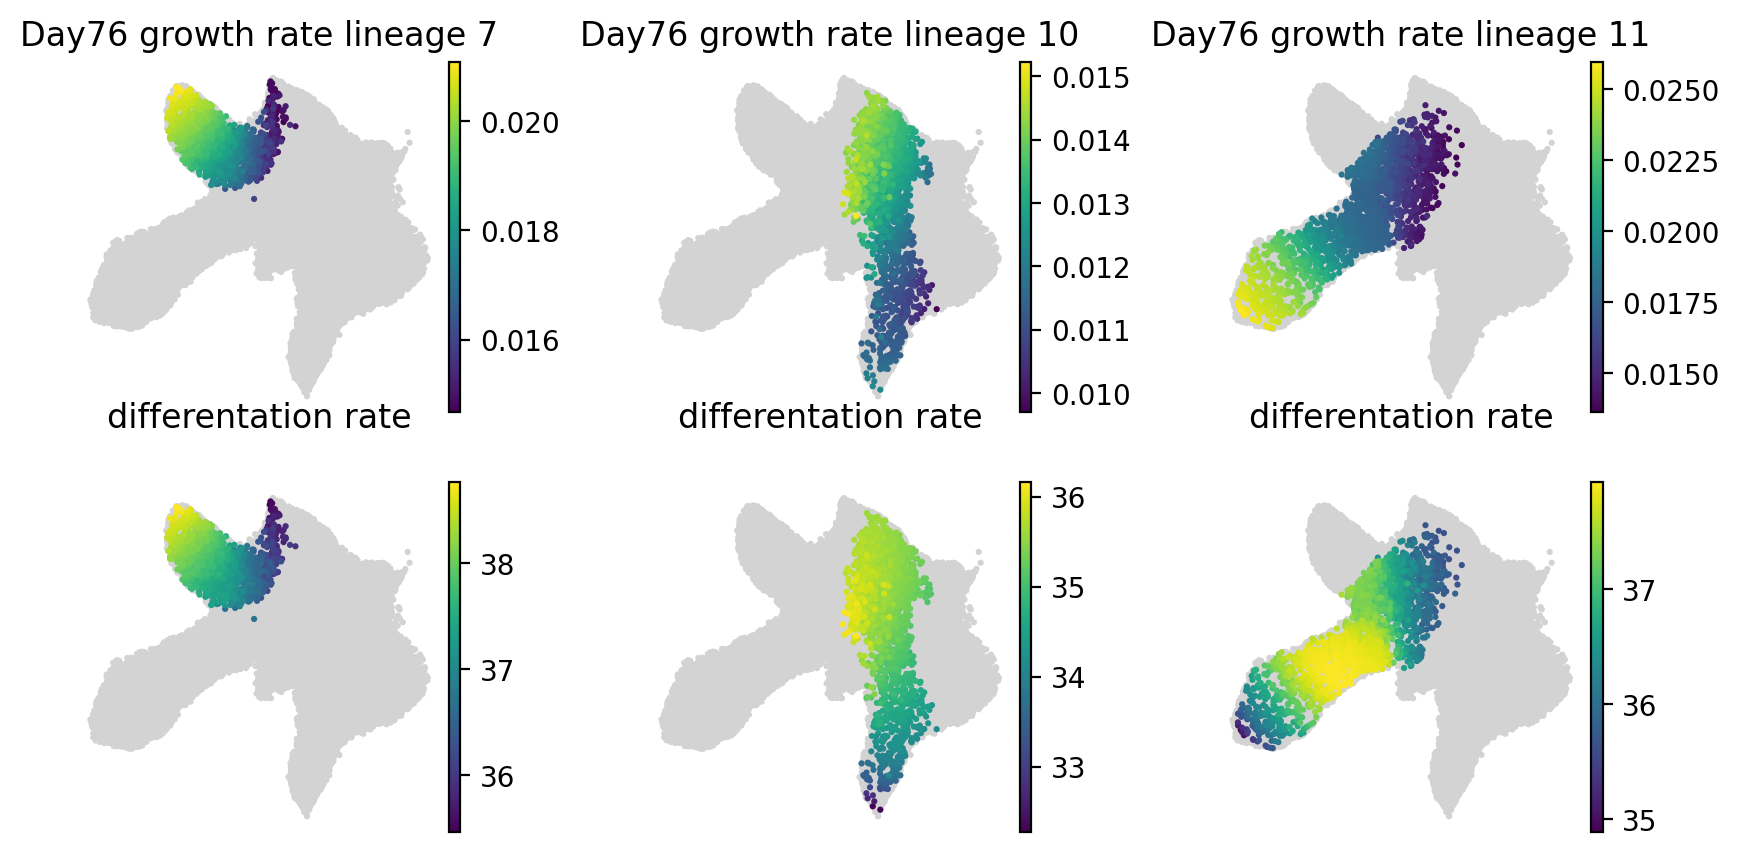

In [6]:
day = 76#49 #161, 269
fig, axs = plt.subplots(2,3,figsize=(10,5), dpi=200, frameon=False, gridspec_kw={'wspace':0.4})
lineages = ['Meg','Neu','Ery']
for i,clu in enumerate([7,10,11]):
    clu = str(clu)
    clu_ad = adata[cb_of_cluster[str(clu)]]
    #vis
    
    sc.pl.umap(adata,  frameon=False, show=False, ax=axs[0,i], size=20)
    sc.pl.umap(adata,  frameon=False, show=False, ax=axs[1,i], size=20)

    sc.pl.umap(clu_ad[clu_ad.obs.timepoint_tx_days==day], color=f'Day{day} g', frameon=False, show=False, ax=axs[0,i], size=20, title=f'Day{day} growth rate lineage {clu}')
    sc.pl.umap(clu_ad[clu_ad.obs.timepoint_tx_days==day], color=f'Day{day} v norm', frameon=False, show=False, ax=axs[1,i], size=20, title=f'differentation rate\n ')

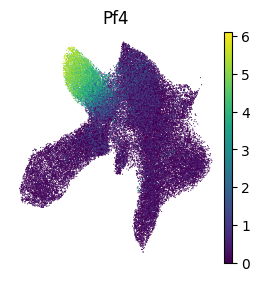

In [7]:
fig=plt.figure(figsize=(3,3), dpi=100)
sc.pl.umap(adata, color='Pf4', legend_loc='on data', frameon=False, ax=fig.gca())

# change by time

In [43]:
agg_param_t = []
g_dfs = []
v_dfs = []

clu_ad = adata[adata.obs.query("`anno_man` != 'Eos'").index]

for t in clu_ad.uns['pop']['t']:
    # param of time
    param_df = clu_ad.obs.query("`timepoint_tx_days` == @t")

    ct_count_dict = param_df.groupby(["anno_man"]).agg({"biosample_id":'count'}).to_dict()['biosample_id']
    param_df['n_cell_ct'] = param_df['anno_man'].map(ct_count_dict).values
    
    g_dfs.append(
        param_df[[f'Day{t} g','anno_man','timepoint_tx_days','n_cell_ct']].rename({f'Day{t} g':'g'}, axis=1)
    )

    v_dfs.append(
        param_df[[f'Day{t} v norm','anno_man','timepoint_tx_days','n_cell_ct']].rename({f'Day{t} v norm':'v'}, axis=1)
    )

    param_df_by_ct = param_df[[f'Day{t} g', f'Day{t} v norm','anno_man']
                              ].groupby("anno_man").agg("mean")
    agg_param_t.append(param_df_by_ct)

agg_param_df = pd.concat(agg_param_t, axis=1)

g_df = pd.concat(g_dfs).astype({'timepoint_tx_days':'str'}).query("`n_cell_ct` > 15")
v_df = pd.concat(v_dfs).astype({'timepoint_tx_days':'str'}).query("`n_cell_ct` > 15")

/tmp/ipykernel_4100358/3219240590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  param_df['n_cell_ct'] = param_df['anno_man'].map(ct_count_dict).values
/tmp/ipykernel_4100358/3219240590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  param_df['n_cell_ct'] = param_df['anno_man'].map(ct_count_dict).values
/tmp/ipykernel_4100358/3219240590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [52]:
import seaborn as sns

Text(0.5, 0, 'Time point (Day)')

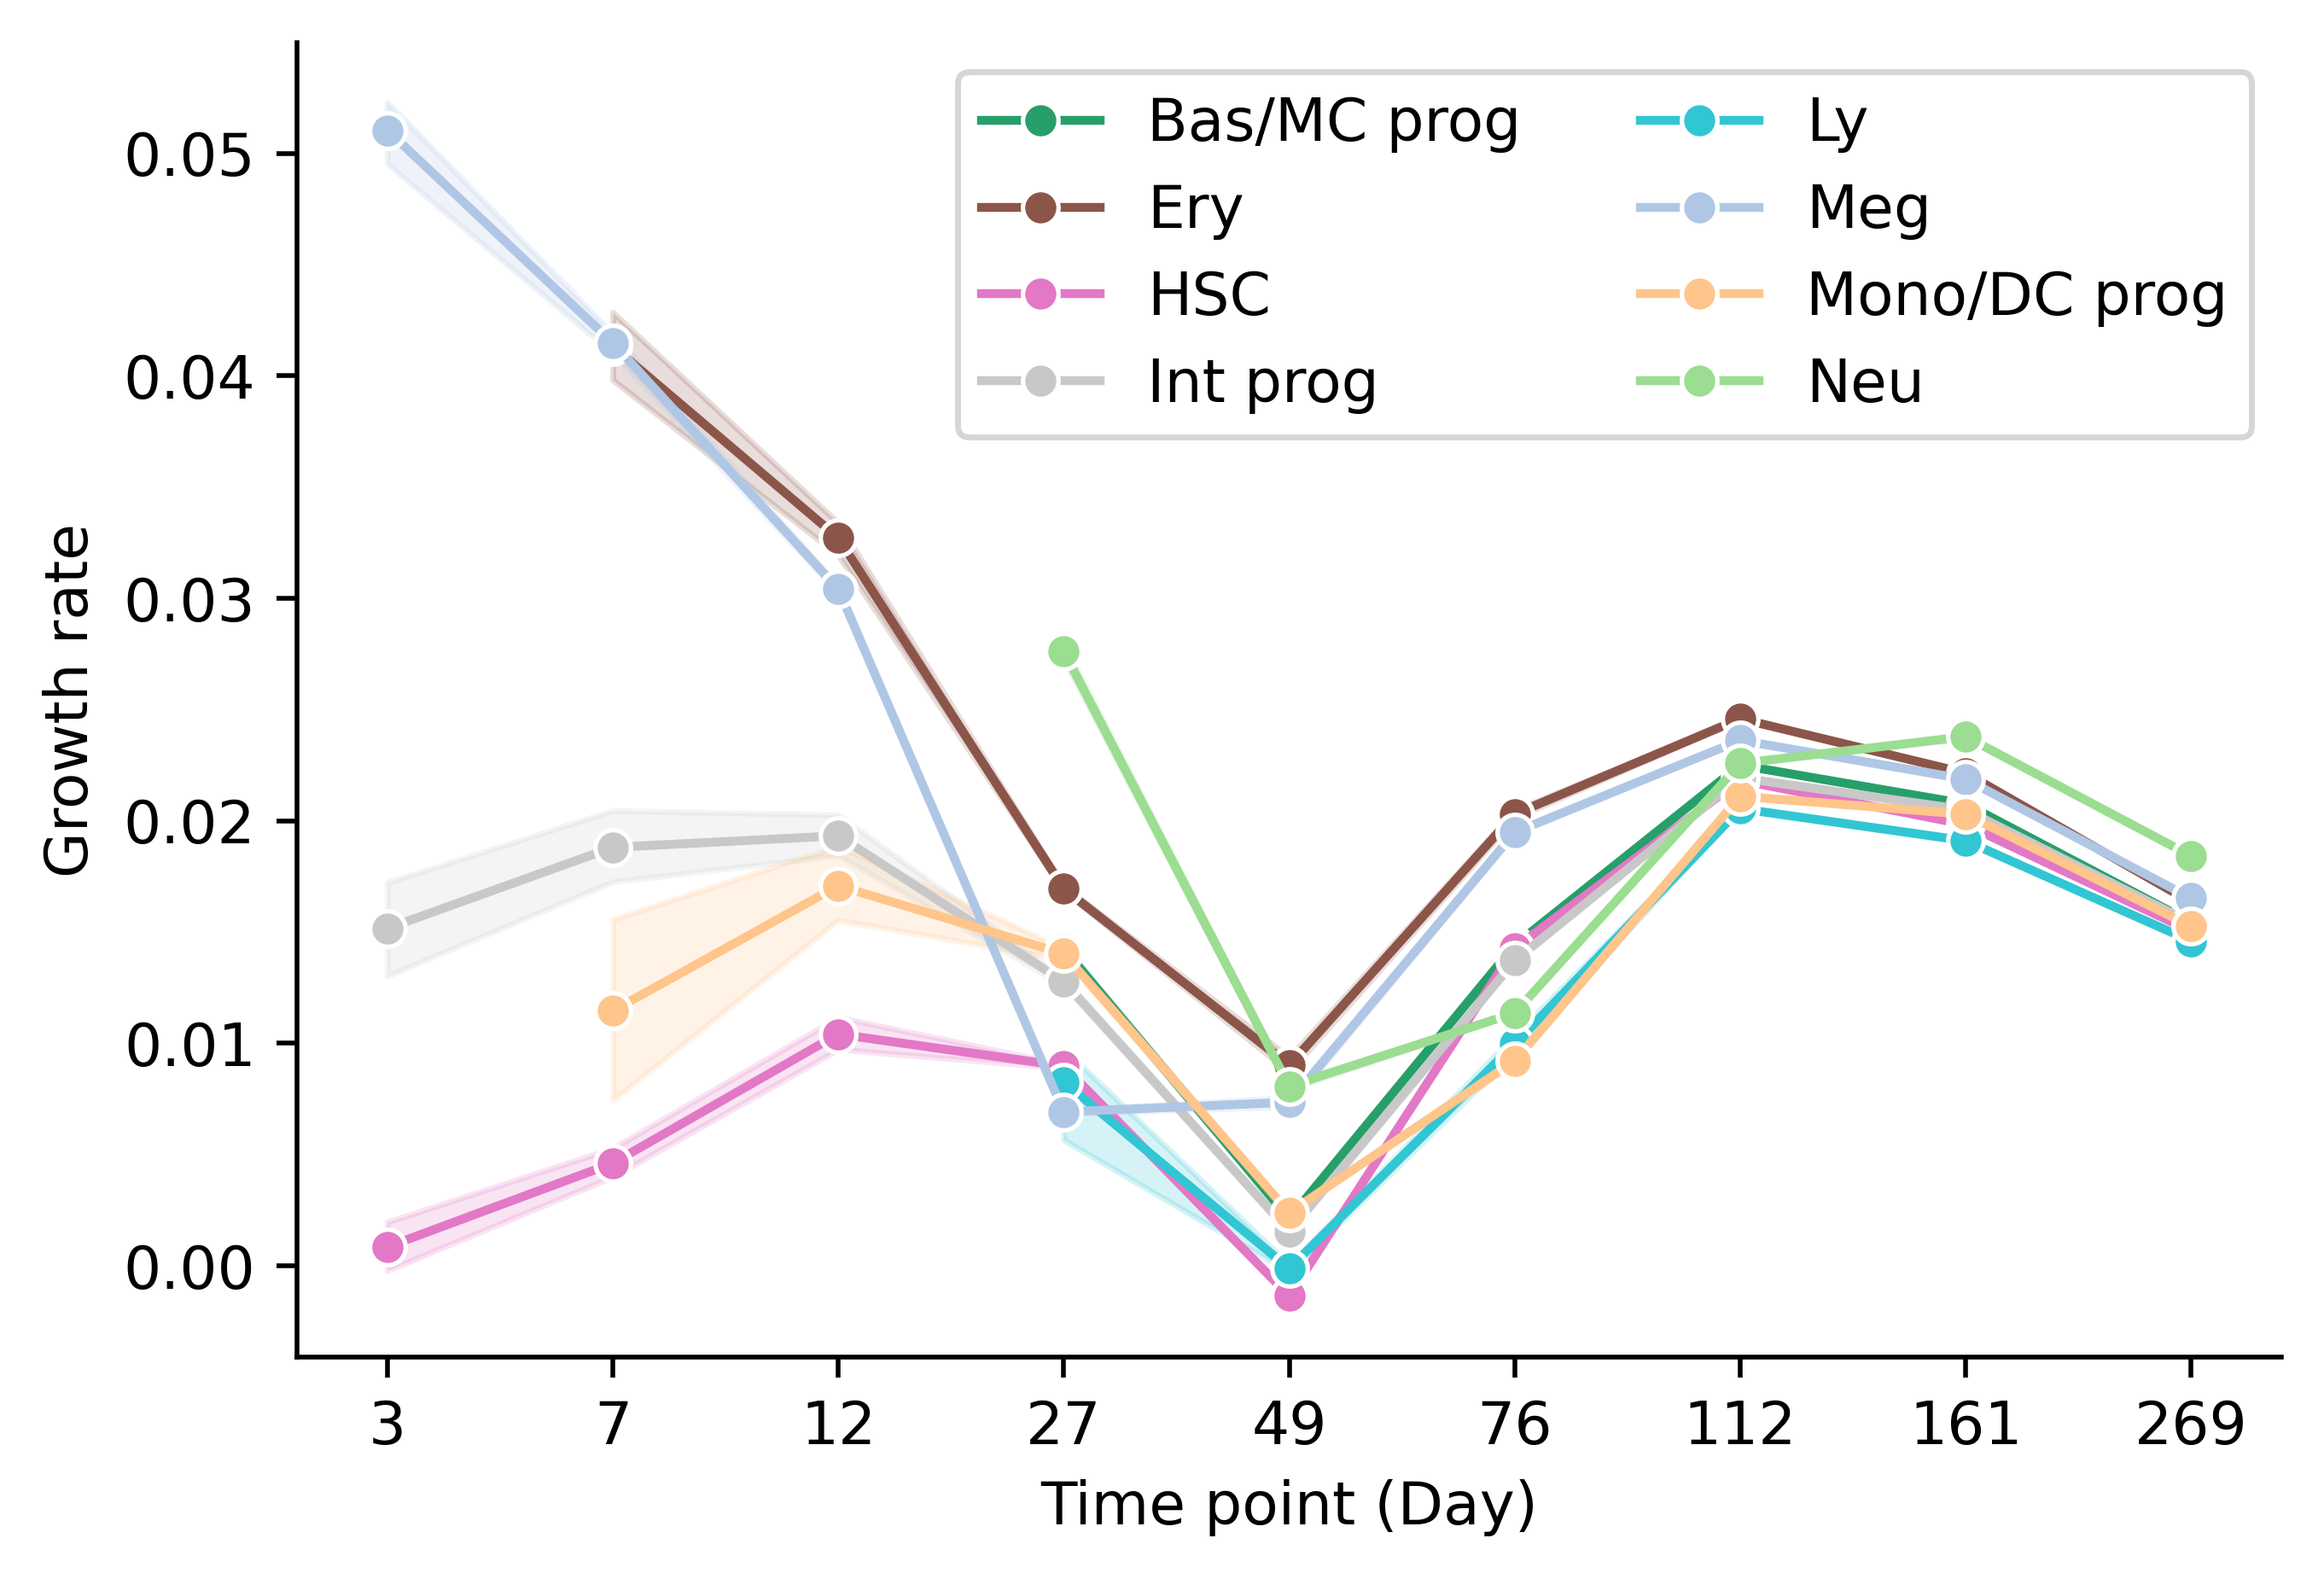

In [54]:
# ct_of_interest = ['HSC', 'Int prog','Ery', 'Meg', 'Neu', 'Mono/DC prog']
plt.figure(dpi=500, figsize=(6,4))
g=sns.lineplot(data=g_df,#.query("`anno_man` in @ct_of_interest"),
              x='timepoint_tx_days', y='g', marker='o',
             hue='anno_man', palette=celltype_pallete)
g.legend(loc='upper right', ncol=2)
sns.despine(ax=g)
g.set_ylabel("Growth rate")
g.set_xlabel("Time point (Day)")

In [49]:
g

<Axes: xlabel='timepoint_tx_days', ylabel='g'>

<Axes: xlabel='timepoint_tx_days', ylabel='g'>

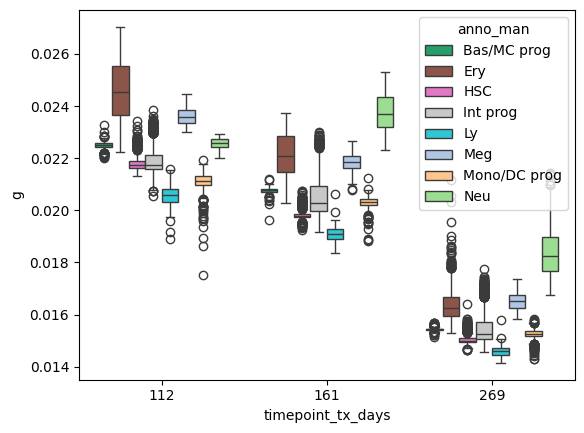

In [57]:
interest_t = ['112','161','269']
sns.boxplot(data=g_df.query("`timepoint_tx_days` in @interest_t"),
              x='timepoint_tx_days', y='g', saturation=1,
             hue='anno_man', palette=celltype_pallete, )

<Axes: xlabel='timepoint_tx_days', ylabel='v'>

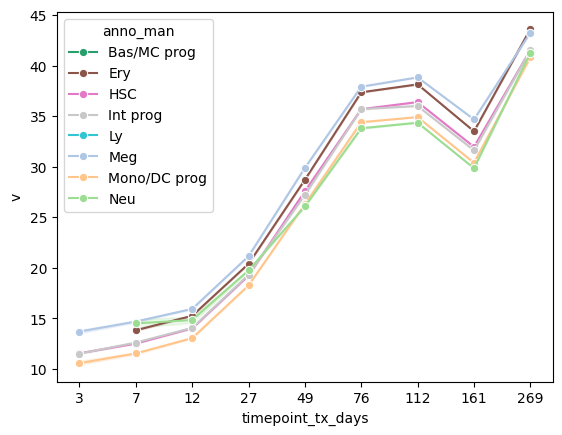

In [ ]:
ct_of_interest = ['HSC', 'Int prog','Ery', 'Meg', 'Neu', 'Mono/DC prog']
sns.lineplot(data=v_df.query("`anno_man` in @ct_of_interest"),
              x='timepoint_tx_days', y='v', marker='o',
             hue='anno_man', palette=celltype_pallete)

# predicting continous growth params

In [7]:
import PINN

In [8]:
device = 'cuda:2'

In [3]:
DS_full = reader.TwoTimpepoint_AnnDS(AnnData=adata, timepoint_idx=None,  
                            n_dimension = 10,
                              cellstate_key='DM_scaled',  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              batchsize=100)

Computing density :
`density_funs` not specified, use gaussian kde


In [6]:
[osm.shape for osm in DS_full.cellstate_t_ls]

[(394, 10),
 (633, 10),
 (613, 10),
 (3357, 10),
 (4444, 10),
 (5184, 10),
 (11323, 10),
 (6947, 10),
 (16495, 10)]

In [ ]:
model_ckpt = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=95-total_loss=1.33532071.ckpt"
model = PINN.models.pde_params.load_from_checkpoint(model_ckpt)
pde_model = model.to(device)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [16]:
pde_model.__getattr__('g')

MLP_surrogate(
  (u_theta): Sequential(
    (Linear_0): Linear(in_features=11, out_features=64, bias=True)
    (Tanh_0): Tanh()
    (Linear_1): Linear(in_features=64, out_features=32, bias=True)
    (Tanh_1): Tanh()
    (Linear_2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [111]:
@torch.no_grad
def continuous_params(pde_model, DataSet, 
                        param = 'g',
                        chunk_size = 1000,
                        groupby_key = None,
                        n_interval = 10,
                        agg_fun = 'mean'):

    param_ls = []

    # <ForLoop1: iterate between timepoint and obsreved cellstate>
    for it, s_ts in tqdm(enumerate(DS_full.cellstate_t_ls[:-1])):
        t = DS_full.T_b[it]
        tp1 = DS_full.T_b[it+1]

        if groupby_key is not None:
            agg_col = []
            real_time = DS_full.popD['t'][it]
            # obs_t = DS_full.adata.obs.query(f"`{DS_full.timepoint_key}` == @real_time").copy()
            obs_t = DS_full.adata.obs.copy()
            obs_t['str_col'] = 'x'
            ct_count_dict = obs_t.query(f"`{DS_full.timepoint_key}` == @real_time").groupby([groupby_key]).agg({"str_col":'count'}).to_dict()['str_col']
        
        # <ForLoop2:iterate with differrent intemediate t>
        for t_mid in np.linspace(t, tp1, n_interval):

            s_ts_gpu = torch.from_numpy(DS_full.cellstate).float().to(device)
            t_ts = torch.full((s_ts_gpu.shape[0],), t_mid).float().to(device)

            # <ForLoop3:forward by chunk>
            param_t = []
            for i in range(0, len(t_ts), chunk_size):                              
                s_in = s_ts_gpu[i:i+chunk_size]
                t_in = t_ts[i:i+chunk_size]

                # forward here
                param_pred = pde_model.__getattr__(param)(s_in, t_in)
                param_t.append(param_pred.detach().cpu().numpy())
            
            param_catchunk = np.concatenate(param_t, axis=0)
            # <ForLoop3>

            if groupby_key is not None:
                obs_t[f"{t_mid}"] = param_catchunk
                agg_col.append(f"{t_mid}")
            else:
                param_ls.append(param_catchunk)
            # <ForLoop2>

        if groupby_key is not None:
            params = obs_t[agg_col+[groupby_key]].groupby(groupby_key).agg(agg_fun)
            params = pd.melt(params.reset_index(), id_vars=groupby_key)
            params['timepoint_tx_day'] = real_time
            params['ct_of_day'] = params[groupby_key].map(ct_count_dict)
            param_ls.append(params)
        # <ForLoop1>

    return param_ls

In [112]:
grouped_param = continuous_params(pde_model, DS_full, groupby_key='anno_man')

0it [00:00, ?it/s]

In [122]:
grouped_param = pd.concat(grouped_param, axis=0)
grouped_param = grouped_param.query("`ct_of_day` > 15")

In [121]:
grouped_param.head()

,anno_man,variable,value,timepoint_tx_day,ct_of_day
0,Bas/MC prog,1.0,0.348390,3,1
1,Eos,1.0,0.937119,3,0
2,Ery,1.0,0.815956,3,8
3,HSC,1.0,0.122148,3,138
4,Int prog,1.0,0.359515,3,199


In [124]:
celltype_pallete

NameError: name 'celltype_pallete' is not defined

Text(0.5, 0, 'Time point (Day)')

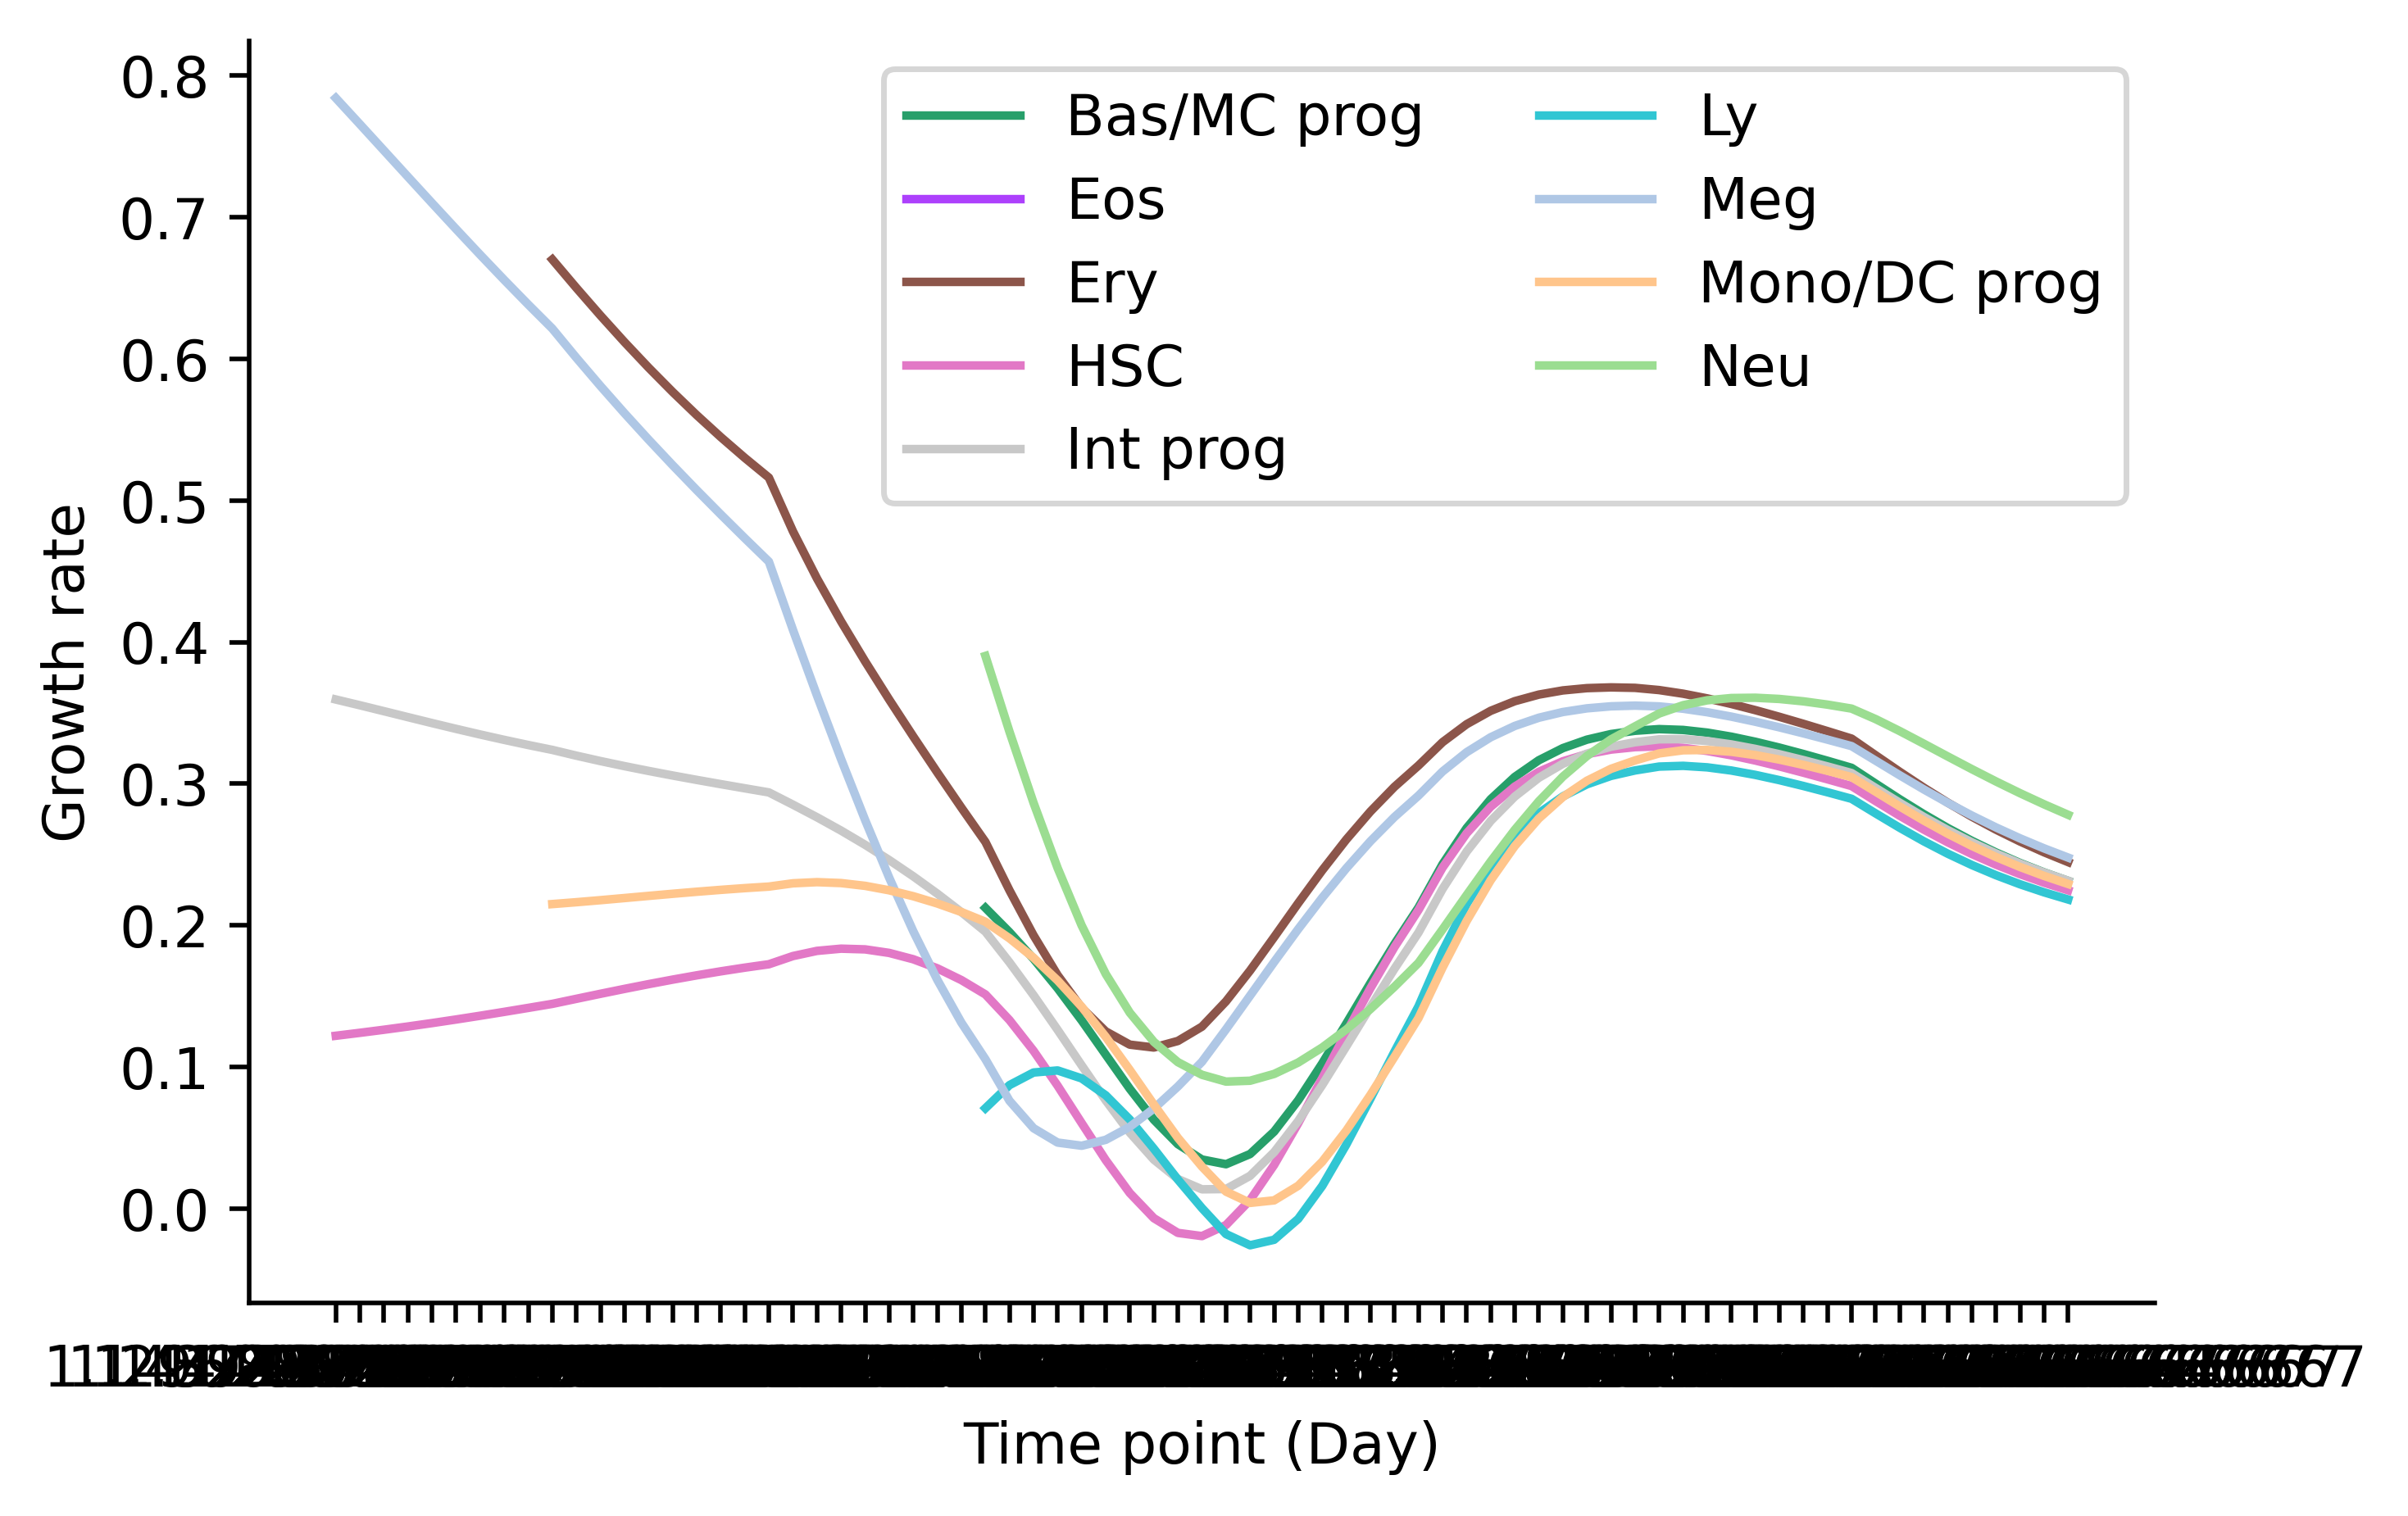

In [126]:
# ct_of_interest = ['HSC', 'Int prog','Ery', 'Meg', 'Neu', 'Mono/DC prog']
plt.figure(dpi=500, figsize=(6,4))
ax = plt.gca()
g = sns.lineplot(data=grouped_param, x='variable', y='value', 
                 hue='anno_man', palette=celltype_pallete,
                 ax=ax
                 )
g.legend(loc='upper right', ncol=2)
sns.despine(ax=g)
g.set_ylabel("Growth rate")
g.set_xlabel("Time point (Day)")